In [ ]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import time
from torchmetrics.classification import MulticlassAccuracy, MulticlassROC, MulticlassConfusionMatrix
from sklearn.metrics import classification_report

/opt/anaconda3/lib/python3.12/site-packages/ignite/handlers/checkpoint.py:16: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import ZeroRedundancyOptimizer


In [ ]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split
from torchinfo import summary
from tqdm import tqdm 

In [3]:
dataset = torchvision.datasets.ImageFolder(root='./datasets/cnn_dataset')

In [4]:
loss_function = nn.CrossEntropyLoss()
PATH = "heejuhwa_assignment2_part4.pt"

In [5]:
def train_val_model(model, optimizer, scheduler, epoch_num=100):
    train_accuracy_hist = []
    train_loss_hist = []
    val_accuracy_hist = []
    val_loss_hist = []
    best_accuracy = 0
    lr_decrease_cnt = 0
    start_time = time.time()
    
    for epoch in range(epoch_num):
        # train
        model.train()
        train_loss = 0.0
        train_accuracy_metric = MulticlassAccuracy(num_classes=36)
        for train_inputs, train_labels in tqdm(train_loader, desc=f"Training Epoch {epoch+1}"):
            optimizer.zero_grad()
            outputs = model(train_inputs)
            loss = loss_function(outputs, train_labels) 
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            predicted = torch.argmax(outputs.data, 1)
            train_accuracy_metric.update(predicted, train_labels)
        train_accuracy_hist.append(train_accuracy_metric.compute().item())
        train_loss_hist.append(train_loss/len(train_loader))
        print(f"Epoch {epoch + 1} - Learning Rate: {scheduler.get_last_lr()[0]:.6f}, Train Accuracy: {train_accuracy_metric.compute().item():.4f}, Train Loss: {train_loss/len(train_loader):.4f}")

        # validation
        model.eval()
        val_loss = 0.0
        val_accuracy_metric = MulticlassAccuracy(num_classes=36)
        with torch.no_grad():
            for val_inputs, val_labels in tqdm(val_loader, desc=f"Validation Epoch {epoch+1}"):
                val_outputs = model(val_inputs)
                val_loss += loss_function(val_outputs, val_labels).item()
                predicted = torch.argmax(val_outputs.data, 1)
                val_accuracy_metric.update(predicted, val_labels)
        val_accuracy = val_accuracy_metric.compute().item()
        val_accuracy_hist.append(val_accuracy)
        val_loss_hist.append(val_loss/len(val_loader))
        scheduler.step(val_accuracy)
    
        if val_accuracy > best_accuracy:
            best_accuracy = val_accuracy
            torch.save(model.state_dict(), PATH)
        elif optimizer.param_groups[0]['lr'] < scheduler.optimizer.defaults['lr']:
            lr_decrease_cnt += 1
        print(f"          Val Accuracy: {val_accuracy:.4f}, Val Loss: {val_loss / len(val_loader):.4f}")

        if lr_decrease_cnt > 4:
            break
            
    train_time = time.time() - start_time
    return {'train_accuracy_hist': train_accuracy_hist, 'train_loss_hist': train_loss_hist, 'val_accuracy_hist': val_accuracy_hist, 'val_loss_hist': val_loss_hist, 'train_time': train_time}

In [10]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_size = int(0.85 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
train_dataset, val_dataset = random_split(train_dataset, [train_size - test_size, test_size])
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = test_transform
test_dataset.dataset.transform = test_transform
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)


class VGG13(nn.Module):
    def __init__(self):
        super(VGG13, self).__init__()
        
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=1)
        )
        self.layer3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.layer4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=1)
        )
        self.layer5 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

        )
        self.fc = nn.Sequential(
            nn.Linear(512 * 8 * 8, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 36)
        )
    
    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x
vgg = VGG13()

vgg_optimizer = optim.Adam(vgg.parameters(), lr=0.1)
vgg_scheduler = optim.lr_scheduler.ReduceLROnPlateau(vgg_optimizer, 'max', patience=2)
result1 = train_val_model(vgg, vgg_optimizer, vgg_scheduler, epoch_num=30)

Training Epoch 1: 100%|███████████████████████| 552/552 [25:10<00:00,  2.74s/it]


Epoch 1 - Learning Rate: 0.100000, Train Accuracy: 0.0278, Train Loss: 129823086715625680.0000


Validation Epoch 1: 100%|█████████████████████| 237/237 [01:36<00:00,  2.46it/s]


          Val Accuracy: 0.0278, Val Loss: 3.5918


Training Epoch 2: 100%|███████████████████████| 552/552 [25:11<00:00,  2.74s/it]


...

          Val Accuracy: 0.0278, Val Loss: 3.5851


Training Epoch 8: 100%|███████████████████████| 552/552 [25:15<00:00,  2.74s/it]


Epoch 8 - Learning Rate: 0.001000, Train Accuracy: 0.0277, Train Loss: 11003953.2798


Validation Epoch 8: 100%|█████████████████████| 237/237 [01:38<00:00,  2.40it/s]

          Val Accuracy: 0.0278, Val Loss: 3.5841


In [10]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((32, 32)),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_size = int(0.85 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
train_dataset, val_dataset = random_split(train_dataset, [train_size - test_size, test_size])
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = test_transform
test_dataset.dataset.transform = test_transform
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)


class VGG13(nn.Module):
    def __init__(self):
        super(VGG13, self).__init__()
        
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.layer3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)

        )
        self.layer4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer5 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

        )
        self.fc = nn.Sequential(
            nn.Linear(512 * 4 * 4, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 36)
        )
    
    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x
vgg = VGG13()

vgg_optimizer = optim.SGD(vgg.parameters(), lr=0.01, momentum=0.9)
vgg_scheduler = optim.lr_scheduler.ReduceLROnPlateau(vgg_optimizer, 'max', patience=2)
result = train_val_model(vgg, vgg_optimizer, vgg_scheduler, epoch_num=30)

Training Epoch 1: 100%|███████████████████████| 552/552 [14:44<00:00,  1.60s/it]


Epoch 1 - Learning Rate: 0.010000, Train Accuracy: 0.0264, Train Loss: 3.5838


Validation Epoch 1: 100%|█████████████████████| 237/237 [00:57<00:00,  4.15it/s]


          Val Accuracy: 0.0278, Val Loss: 3.5839


Training Epoch 2: 100%|███████████████████████| 552/552 [14:41<00:00,  1.60s/it]


...

          Val Accuracy: 0.0278, Val Loss: 3.5838


Training Epoch 8: 100%|███████████████████████| 552/552 [14:47<00:00,  1.61s/it]


Epoch 8 - Learning Rate: 0.000100, Train Accuracy: 0.0279, Train Loss: 3.5835


Validation Epoch 8: 100%|█████████████████████| 237/237 [00:56<00:00,  4.19it/s]

          Val Accuracy: 0.0278, Val Loss: 3.5838


In [24]:
summary(vgg, input_size=(128, 1, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
VGG13                                    [128, 36]                 --
├─Sequential: 1-1                        [128, 64, 16, 16]         --
│    └─Conv2d: 2-1                       [128, 64, 32, 32]         640
│    └─ReLU: 2-2                         [128, 64, 32, 32]         --
│    └─Conv2d: 2-3                       [128, 64, 32, 32]         36,928
│    └─ReLU: 2-4                         [128, 64, 32, 32]         --
│    └─MaxPool2d: 2-5                    [128, 64, 16, 16]         --
├─Sequential: 1-2                        [128, 128, 16, 16]        --
│    └─Conv2d: 2-6                       [128, 128, 16, 16]        73,856
│    └─ReLU: 2-7                         [128, 128, 16, 16]        --
│    └─Conv2d: 2-8                       [128, 128, 16, 16]        147,584
│    └─ReLU: 2-9                         [128, 128, 16, 16]        --
├─Sequential: 1-3                        [128, 256, 8, 8]          --
│

In [11]:
def test_model(model):
    # test
    model.load_state_dict(torch.load(PATH, weights_only=True))
    accuracy_metric = MulticlassAccuracy(num_classes=36)
    all_labels = torch.tensor([])
    all_outputs = torch.tensor([])
    all_preds = torch.tensor([])
    test_loss = 0
    with torch.no_grad():
        for test_inputs, test_labels in test_loader:
            test_outputs = model(test_inputs)
            loss = loss_function(test_outputs, test_labels)
            test_loss += loss.item()
            predicted = torch.argmax(test_outputs.data, dim=1)
            all_labels = torch.cat((all_labels, test_labels), dim=0)
            all_outputs = torch.cat((all_outputs, test_outputs), dim=0)
            all_preds = torch.cat((all_preds, predicted), dim=0)
            accuracy_metric.update(predicted, test_labels)
    test_loss = test_loss/len(test_loader)
    
    print(f'Accuracy: {accuracy_metric.compute().item():.4f}, Test Loss: {test_loss:.4f}')
    return {'test_accuracy': accuracy_metric.compute().item(), 'test_loss': test_loss, 'test_labels': all_labels, 'test_predicted': all_preds, 'test_outputs': all_outputs}

In [12]:
vgg = VGG13()
test_result = test_model(vgg)

Accuracy: 0.0289, Test Loss: 3.5841


In [13]:
test_accuracy = test_result['test_accuracy']
test_loss = test_result['test_loss']

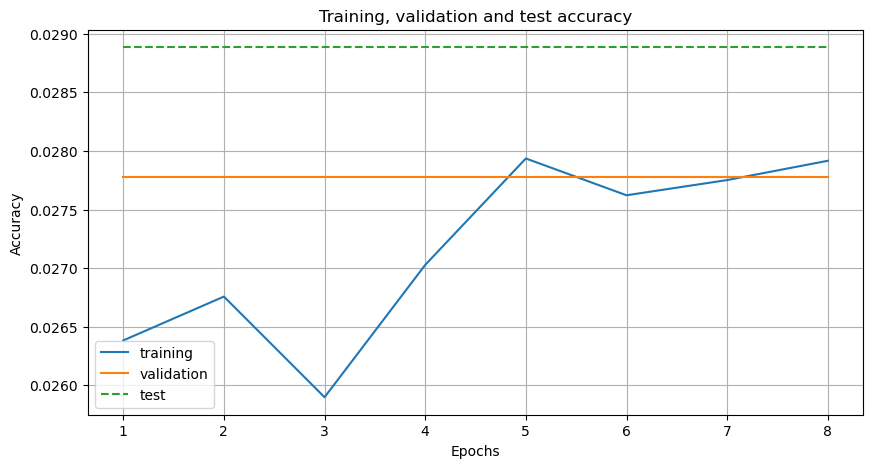

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, 9), result['train_accuracy_hist'], label='training')
plt.plot(range(1, 9), result['val_accuracy_hist'], label='validation')
plt.plot(range(1, 9), [test_accuracy] * 8, label='test', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training, validation and test accuracy')
plt.legend()
plt.grid(True)
plt.show()

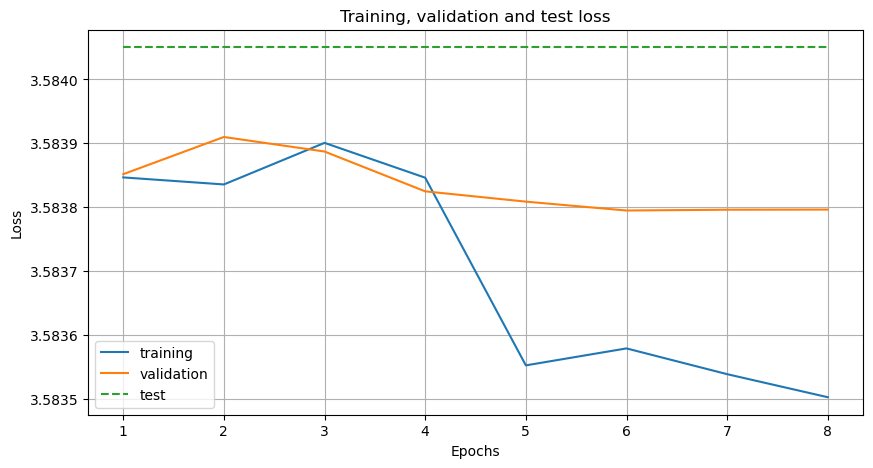

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, 9), result['train_loss_hist'], label='training')
plt.plot(range(1, 9), result['val_loss_hist'], label='validation')
plt.plot(range(1, 9), [test_loss] * 8, label='test', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training, validation and test loss')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
y_true = test_result['test_labels']
y_pred = test_result['test_predicted']
classes = dataset.classes

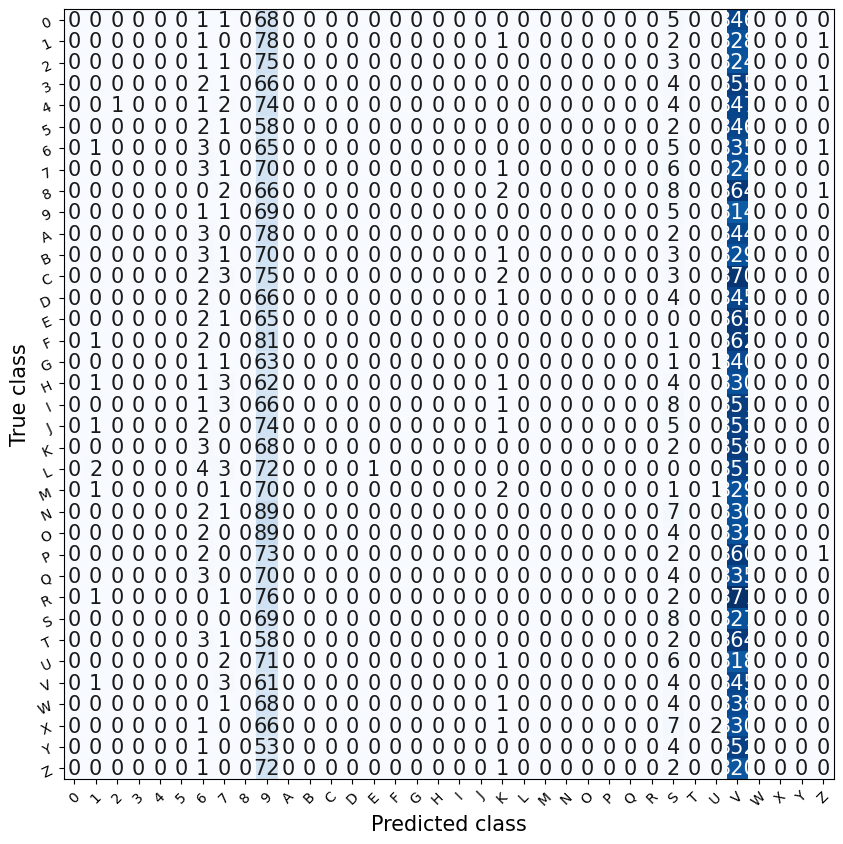

In [20]:
metric = MulticlassConfusionMatrix(num_classes=36)
metric.update(y_pred, y_true)
fig_, ax_ = plt.subplots(figsize=(10, 10))
conf_matrix_plot = metric.plot(labels=classes, cmap='Blues', ax=ax_)

In [21]:
print(classification_report(y_true, y_pred, target_names=classes))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       421
           1       0.00      0.00      0.00       411
           2       0.00      0.00      0.00       404
           3       0.00      0.00      0.00       429
           4       0.00      0.00      0.00       429
           5       0.00      0.00      0.00       409
           6       0.05      0.01      0.01       410
           7       0.03      0.00      0.00       405
           8       0.00      0.00      0.00       443
           9       0.03      0.18      0.05       390
           A       0.00      0.00      0.00       427
           B       0.00      0.00      0.00       407
           C       0.00      0.00      0.00       455
           D       0.00      0.00      0.00       418
           E       0.00      0.00      0.00       433
           F       0.00      0.00      0.00       447
           G       0.00      0.00      0.00       407
           H       0.00    

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [22]:
y_outputs = test_result['test_outputs']
roc = MulticlassROC(num_classes=36)
fpr, tpr, thresholds = roc(y_outputs, y_true.to(dtype=torch.long))

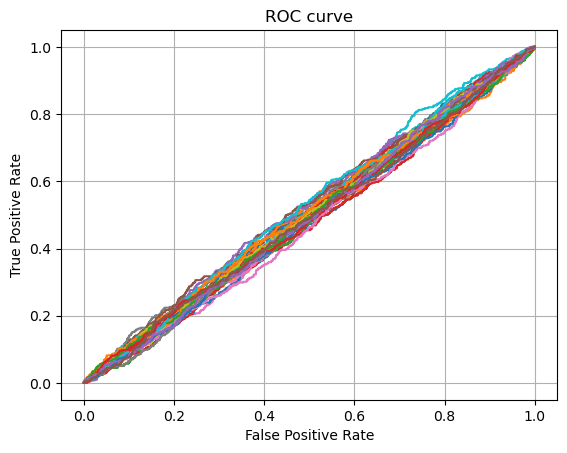

In [23]:
for i in range(len(fpr)):  
    plt.plot(fpr[i], tpr[i])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve')
plt.grid()
plt.show()

### Reference
- Assignment 2 part 1 preprocessing, test
- Assignment 2 part 2 preprocessing, optimization
- https://pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html#imagefolder
- https://medium.com/jun94-devpblog/pytorch-1-transform-imagefolder-dataloader-7f75f0a460c0
- https://www.programcreek.com/python/example/105102/torchvision.datasets.ImageFolder
- https://pytorch.org/vision/0.8/transforms.html?highlight=transforms
- https://pytorch.org/tutorials/beginner/basics/data_tutorial.html
- https://github.com/TylerYep/torchinfo
- https://lightning.ai/docs/torchmetrics/stable/classification/accuracy.html
- https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ReduceLROnPlateau.html
- https://lightning.ai/docs/torchmetrics/stable/classification/confusion_matrix.html
- https://matplotlib.org/stable/users/explain/colors/colormaps.html
- https://lightning.ai/docs/torchmetrics/stable/classification/roc.html